# Machine Learning #01 -  Basic Neural Network in PyTorch 🦥

We will **train a small neural network** to make a
prediction — all in [PyTorch](https://pytorch.org/), one of the most widely used
deep-learning libraries.

We will keep the network **deliberately simple**. The goal is *not* a fancy
architecture, but to understand the **complete PyTorch workflow**:

> **data → tensors → model → loss → training loop → evaluation → interpretation**

## What is PyTorch? 🔥

**PyTorch** is a Python library for building and training neural networks.
Two ideas are enough to get started:

- **Tensors** — multi-dimensional arrays, very similar to NumPy arrays, but they
  can run on a **GPU** and can **remember how they were computed** so gradients can
  be calculated automatically.
- **Autograd** — PyTorch's **automatic differentiation** engine. It computes the
  gradients (derivatives) needed for learning *for you*.

### How is this different from scikit-learn?

In scikit-learn you usually call `model.fit(X, y)` and everything happens inside.
In PyTorch **you write the training loop yourself**. That is more work, but it is
also the source of PyTorch's flexibility — and understanding that loop is the whole
point of today's lesson.

| | scikit-learn | PyTorch |
|---|---|---|
| Training | one call: `model.fit(X, y)` | **you write the training loop** |
| Data format | NumPy arrays | **tensors** |
| Gradients | hidden from you | **explicit** (autograd) |
| Typical use | classic ML models | neural networks / deep learning |

Let's look at a tensor before we do anything else.

## Imports and setup
Remember to set **GPU** runtime in Colab!

In [2]:
!pip install torchinfo

In [3]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn

import torchinfo

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, confusion_matrix

sns.set_theme(style="whitegrid")

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("torch version:", torch.__version__)
print("device:", device)

torch version: 2.11.0+cu128
device: cuda


## The dataset

**Source:** [Species of sloths (Kaggle)](https://www.kaggle.com/datasets/bertiemackie/sloth-species)


| Variable | Meaning |
|---|---|
| `claw_length_cm` | Claw length in cm |
| `size_cm` | Body size in cm |
| `tail_length_cm` | Tail length in cm |
| `weight_kg` | Weight in kg |
| `sub_specie` | One of 6 sub-species  |
| `endangered` | Conservation status |
| `specie` | two-toed vs three-toed |


## Load the data


In [4]:
CSV_PATH = "/content/sloth_data.csv"   # in Colab: upload the file; locally: use "sloth_data.csv"

df = pd.read_csv(CSV_PATH)
df.head()

,Unnamed: 0,claw_length_cm,endangered,size_cm,specie,sub_specie,tail_length_cm,weight_kg
0,0,6.825,critically_endangered,52.004,three_toed,Pygmy three-toed sloth,4.448,3.570
1,1,8.260,critically_endangered,50.082,three_toed,Pygmy three-toed sloth,6.286,2.844
2,2,8.662,critically_endangered,51.498,three_toed,Pygmy three-toed sloth,4.551,1.259
3,3,8.467,critically_endangered,50.122,three_toed,Pygmy three-toed sloth,6.983,2.392
4,4,7.104,critically_endangered,51.364,three_toed,Pygmy three-toed sloth,5.411,3.163


## A quick look at the data 🔎

We keep exploration **short** here — just enough to understand the task. Two things matter before modelling:

1. **Are the classes balanced?** (Roughly equal numbers of each species?)
2. **Do the features actually separate the classes?**

specie
three_toed    2662
two_toed      2338
Name: count, dtype: int64


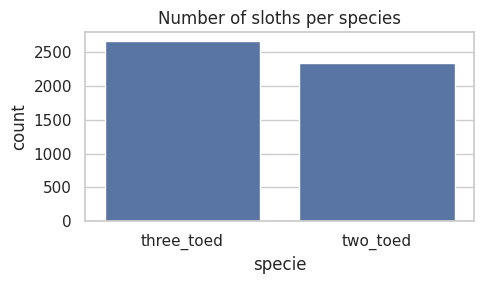

In [5]:
print(df["specie"].value_counts())

plt.figure(figsize=(5, 3))
sns.countplot(data=df, x="specie")
plt.title("Number of sloths per species")
plt.tight_layout()
plt.show()

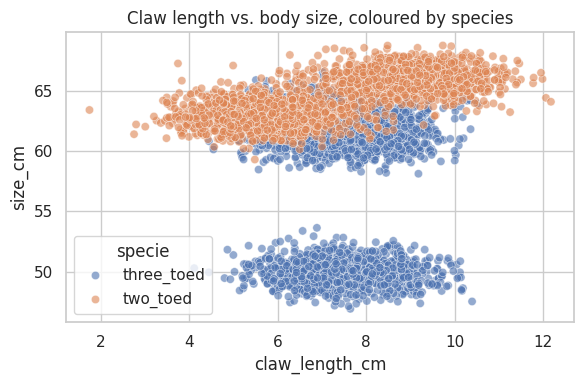

In [6]:
plt.figure(figsize=(6, 4))
sns.scatterplot(data=df, x="claw_length_cm", y="size_cm",
                hue="specie", alpha=0.6)
plt.title("Claw length vs. body size, coloured by species")
plt.tight_layout()
plt.show()

## Preprocessing 🧹

A neural network cannot read a raw DataFrame — it needs **numeric tensors**. We do
four things:

1. **Select** the feature columns `X` and the target column `y`.
2. **Encode** the text labels (`two_toed`/`three_toed`) into numbers `0`/`1`.
3. **Split** the data into a **training** set (to learn from) and a **test** set
   (to check honestly on unseen data).
4. **Scale** the features.


In [7]:
feature_cols = ["claw_length_cm", "size_cm", "tail_length_cm", "weight_kg"]
target_col   = "specie"

In [8]:
X = df[feature_cols].values          # shape: (n_samples, n_features)
y_text = df[target_col].values

In [9]:
X

array([[ 6.825, 52.004,  4.448,  3.57 ],
       [ 8.26 , 50.082,  6.286,  2.844],
       [ 8.662, 51.498,  4.551,  1.259],
       ...,
       [ 4.941, 62.091,  1.905,  5.194],
       [ 6.176, 62.039,  1.164,  5.035],
       [ 3.494, 64.043,  1.512,  6.384]])

In [10]:
X.shape

(5000, 4)

In [11]:
y_text

array(['three_toed', 'three_toed', 'three_toed', ..., 'two_toed',
       'two_toed', 'two_toed'], dtype=object)

In [12]:
label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y_text)

print("Label mapping:")
for i, name in enumerate(label_encoder.classes_):
    print(f"  {name}  ->  {i}")

Label mapping:
  three_toed  ->  0
  two_toed  ->  1


In [13]:
y

array([0, 0, 0, ..., 1, 1, 1])

In [14]:
y.shape

(5000,)

In [15]:
X_temp, X_test, y_temp, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=SEED,
    stratify=y,
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.25, random_state=SEED, stratify=y_temp
)

In [16]:
X_train.shape, X_test.shape, X_val.shape, y_train.shape, y_val.shape,  y_test.shape

((3000, 4), (1000, 4), (1000, 4), (3000,), (1000,), (1000,))

In [17]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test  = scaler.transform(X_test)


In [18]:
X_train[0]

array([ 1.68129457,  0.73610227, -0.9041842 , -0.19770923])

### From NumPy to tensors

Finally we convert the arrays into **PyTorch tensors**.

- Features become **`float32`** tensors (networks work in floating point).
- The target becomes a **`float32`** column of shape `(n, 1)` — this shape matches
  the single output of our network and the loss function we will use.

In [19]:
X_train.dtype

dtype('float64')

In [20]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float32).to(device)
X_val_tensor   = torch.tensor(X_val,   dtype=torch.float32).to(device)
X_test_tensor  = torch.tensor(X_test,  dtype=torch.float32).to(device)

In [21]:
X_train_tensor.dtype

torch.float32

In [22]:
X_train.shape

(3000, 4)

In [23]:
X_train_tensor.shape

torch.Size([3000, 4])

In [24]:
y_train.dtype

dtype('int64')

In [25]:
y_train

array([1, 1, 1, ..., 1, 1, 0])

In [26]:
y_train_tensor = torch.tensor(y_train, dtype=torch.float32).reshape(-1, 1).to(device)
y_val_tensor   = torch.tensor(y_val,   dtype=torch.float32).reshape(-1, 1).to(device)
y_test_tensor  = torch.tensor(y_test,  dtype=torch.float32).reshape(-1, 1).to(device)

In [27]:
y_train_tensor.dtype

torch.float32

In [28]:
y_train_tensor

tensor([[1.],
        [1.],
        [1.],
        ...,
        [1.],
        [1.],
        [0.]], device='cuda:0')

## Build the network 🧠

Our network is a tiny **feed-forward** (fully connected) network:

$$\text{input (4 features)} \;\rightarrow\; \text{hidden layer (16 neurons)} \;\rightarrow\; \text{ReLU} \;\rightarrow\; \text{output (1 number)}$$

- A **`nn.Linear(in, out)`** layer computes $z = Wx + b$ (a weighted sum plus bias).
- **`nn.ReLU`** is the activation function $\text{ReLU}(z) = \max(0, z)$. It adds
  **non-linearity**, letting the network learn curved boundaries instead of just a
  straight line.
- The **output is a single number** (called a *logit*). Later we turn it into a
  probability with the **sigmoid** function
  $\sigma(z) = \dfrac{1}{1 + e^{-z}}$, which squeezes any number into the range
  $(0, 1)$.

We stack the layers with **`nn.Sequential`**, the simplest way to define a model.

### nn.Sequential

In [29]:
model = nn.Sequential(
    nn.Linear(4, 16),  # 4 inputs -> 16
    nn.ReLU(),         # non-linearity
    nn.Linear(16, 1),  # 16 -> 1 output (a single logit)
).to(device)

print(model)

Sequential(
  (0): Linear(in_features=4, out_features=16, bias=True)
  (1): ReLU()
  (2): Linear(in_features=16, out_features=1, bias=True)
)


In [30]:
torchinfo.summary(model, input_size=(1, 4))

Layer (type:depth-idx)                   Output Shape              Param #
Sequential                               [1, 1]                    --
├─Linear: 1-1                            [1, 16]                   80
├─ReLU: 1-2                              [1, 16]                   --
├─Linear: 1-3                            [1, 1]                    17
Total params: 97
Trainable params: 97
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

> 💡 The output layer has **exactly 1 neuron**. Why? Because this
> is **binary** classification: one number is enough to express "how much does the
> model lean towards class 1". (For 3+ classes we would need one output per class)

#### Loss function and optimizer ⚖️

To *train* a network we need two more pieces:

- A **loss function** measures how wrong the predictions are (lower = better).
  For binary classification we use **`BCEWithLogitsLoss`** (Binary Cross-Entropy).
  Conveniently, it applies the sigmoid internally, so we feed it the raw logits.

  $$L = -\big[\,y\,\log(p) + (1-y)\,\log(1-p)\,\big]$$

- An **optimizer** updates the weights to reduce the loss. We use **Adam**, a
  reliable default. Conceptually it performs **gradient descent**:

  $$w \leftarrow w - \text{lr}\cdot \frac{\partial L}{\partial w}$$

  where **`lr`** (learning rate) controls the step size.

In [31]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

print("Loss:", criterion)
print("Optimizer:", optimizer.__class__.__name__, "| lr = 0.01")

Loss: BCEWithLogitsLoss()
Optimizer: Adam | lr = 0.01


#### The training loop ⭐ (the heart of PyTorch)

This is the most important part of the whole lesson. **One epoch = one pass over
the data.** In each epoch we repeat the same four steps:

1. **Forward pass** — feed the inputs through the model to get predictions.
2. **Compute the loss** — how wrong are those predictions?
3. **Backward pass** — `loss.backward()` computes the gradients (autograd!).
4. **Update** — `optimizer.step()` nudges the weights to reduce the loss.

There is one easy-to-forget line: **`optimizer.zero_grad()`**. PyTorch *accumulates*
gradients by default, so we must **reset them to zero** before each backward pass.
Forgetting it is the classic PyTorch bug.

In [32]:
n_epochs = 100
history = {"train_loss": [], "val_loss": []}

for epoch in range(n_epochs):
    model.train()
    train_loss = criterion(model(X_train_tensor), y_train_tensor)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()


    model.eval()
    with torch.no_grad():
        val_loss = criterion(model(X_val_tensor), y_val_tensor)

    history["train_loss"].append(train_loss.item())
    history["val_loss"].append(val_loss.item())

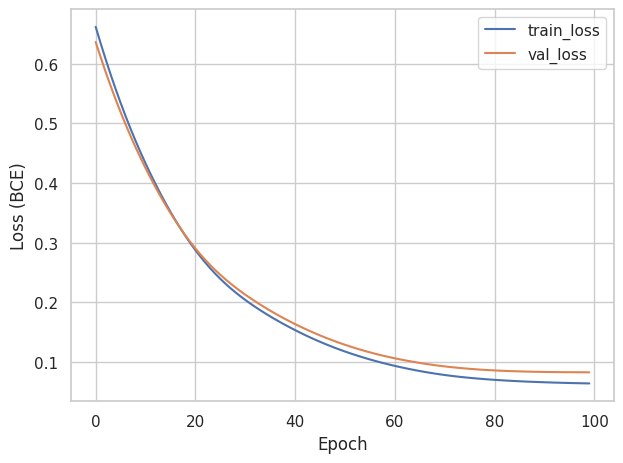

In [33]:
plt.figure()
for key, values in history.items():
    plt.plot(values, label=key)
plt.xlabel("Epoch"); plt.ylabel("Loss (BCE)")
plt.legend(); plt.tight_layout(); plt.show()

> 💡 Watch the printed loss: it should **go down** over the epochs.
> A steadily decreasing loss means the network is **learning**. What do you think
> would happen if the learning rate were far too large?

#### Evaluation 📊

Training loss tells us how well the model fits the **training** data. What we really
care about is performance on the **test** set — data the model has never seen.

For evaluation we:

- switch to **`model.eval()`** mode,
- wrap the forward pass in **`torch.no_grad()`** (we are not learning now, so we
  don't need gradients — this is faster and cleaner),
- turn logits into probabilities with **sigmoid**, then into class predictions
  using a **0.5 threshold**.

In [34]:
model.eval()                       # evaluation mode
with torch.no_grad():              # no gradients needed for evaluation
    test_logits = model(X_test_tensor)
    test_probs  = torch.sigmoid(test_logits)   # logits -> probabilities in (0,1)
    test_preds  = (test_probs >= 0.5).float()  # probability -> class 0/1

In [35]:
y_true = y_test_tensor.cpu().numpy().ravel()
y_pred = test_preds.cpu().numpy().ravel()

accuracy = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {accuracy:.3f}")

Test accuracy: 0.974


### nn.Module
`nn.Sequential` is the easiest way to build a network, but it can only do **one
straight line** of layers: one input, layers stacked back to back, one output.
For anything more flexible, PyTorch offers the `nn.Module` **class**. It does
**exactly the same thing** as `nn.Sequential` — you just write the flow of data
yourself, which gives you control that `Sequential` cannot.


In [36]:
class SlothNet(nn.Module):
    def __init__(self, n_features):
        super().__init__()                     # 1) required first line
        self.fc1 = nn.Linear(n_features, 16)   # 2) define the layers
        self.fc2 = nn.Linear(16, 1)

    def forward(self, x):                       # 3) describe the data flow
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

Both networks are **indistinguishable** — same layers, same number of parameters,
same behaviour. In `Sequential` the order is fixed by the list; in `nn.Module` the
order is defined by the `forward` method.

**Why bother with a class?** 🤔

Because `Sequential` only supports a straight queue. As soon as you need something
more complex, `forward` lets you express it:

- **branching** — send data down two paths and merge them again,
- **skip / residual connections** — add a layer's input to its output (`x + self.fc(x)`),
- **reusing a layer**, conditionals, intermediate computations, multiple inputs/outputs.

None of this is possible with `Sequential`. Our simple network today does not need
it — which is why we keep using `Sequential`.


**What does *not* change at all** 🎯

Whether you build the network with `Sequential` or `nn.Module`, **the rest of the
code is identical**. The training loop, loss, optimizer and evaluation all work the
same, because both are `nn.Module` under the hood:

In [37]:
model_slothnet = SlothNet(4).to(device)
print(model_slothnet)

SlothNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


In [38]:
torchinfo.summary(model_slothnet, input_size=(1, 4))

Layer (type:depth-idx)                   Output Shape              Param #
SlothNet                                 [1, 1]                    --
├─Linear: 1-1                            [1, 16]                   80
├─Linear: 1-2                            [1, 1]                    17
Total params: 97
Trainable params: 97
Non-trainable params: 0
Total mult-adds (Units.MEGABYTES): 0.00
Input size (MB): 0.00
Forward/backward pass size (MB): 0.00
Params size (MB): 0.00
Estimated Total Size (MB): 0.00

In [39]:
criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_slothnet.parameters(), lr=0.01)

In [40]:
n_epochs = 100
history = {"train_loss": [], "val_loss": []}

for epoch in range(n_epochs):
    model_slothnet.train()
    train_loss = criterion(model_slothnet(X_train_tensor), y_train_tensor)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()


    model_slothnet.eval()
    with torch.no_grad():
        val_loss = criterion(model_slothnet(X_val_tensor), y_val_tensor)

    history["train_loss"].append(train_loss.item())
    history["val_loss"].append(val_loss.item())

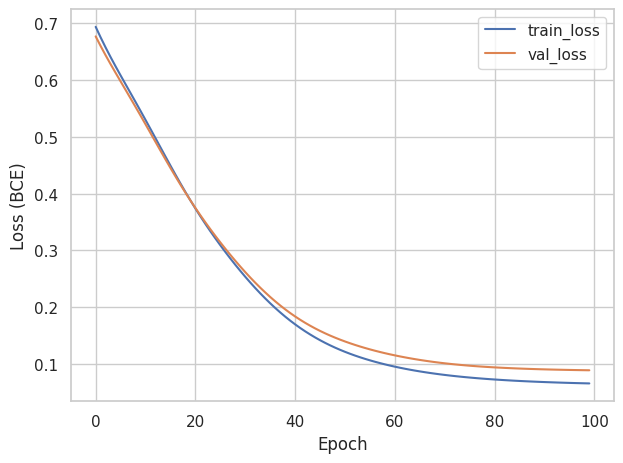

In [41]:
plt.figure()
for key, values in history.items():
    plt.plot(values, label=key)
plt.xlabel("Epoch"); plt.ylabel("Loss (BCE)")
plt.legend(); plt.tight_layout(); plt.show()

In [42]:
model.eval()                       # evaluation mode
with torch.no_grad():              # no gradients needed for evaluation
    test_logits = model(X_test_tensor)
    test_probs  = torch.sigmoid(test_logits)   # logits -> probabilities in (0,1)
    test_preds  = (test_probs >= 0.5).float()  # probability -> class 0/1

In [43]:
y_true = y_test_tensor.cpu().numpy().ravel()
y_pred = test_preds.cpu().numpy().ravel()

accuracy = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {accuracy:.3f}")

Test accuracy: 0.974


# Activities ✏️

Now it is your turn to change the code.


## Activity 1 — Tune the hyperparameters  🎚️

The **learning rate** and the **number of epochs** strongly affect training.

Then try at least **three** learning rates and compare. Re-run the training with a
fresh model each time (the helper below rebuilds the model so results are fair).

SlothNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


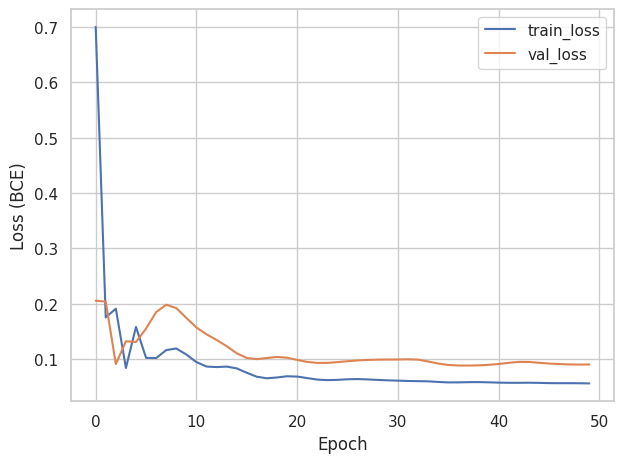

Test accuracy: 0.973


In [49]:
model_slothnet1 = SlothNet(4).to(device)
print(model_slothnet1)

torchinfo.summary(model_slothnet1, input_size=(1, 4))

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_slothnet1.parameters(), lr=0.5)

n_epochs = 50
history = {"train_loss": [], "val_loss": []}

for epoch in range(n_epochs):
    model_slothnet1.train()
    train_loss = criterion(model_slothnet1(X_train_tensor), y_train_tensor)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()


    model_slothnet1.eval()
    with torch.no_grad():
        val_loss = criterion(model_slothnet1(X_val_tensor), y_val_tensor)

    history["train_loss"].append(train_loss.item())
    history["val_loss"].append(val_loss.item())

plt.figure()
for key, values in history.items():
    plt.plot(values, label=key)
plt.xlabel("Epoch"); plt.ylabel("Loss (BCE)")
plt.legend(); plt.tight_layout(); plt.show()

model_slothnet1.eval()                       # evaluation mode
with torch.no_grad():              # no gradients needed for evaluation
    test_logits = model_slothnet1(X_test_tensor)
    test_probs  = torch.sigmoid(test_logits)   # logits -> probabilities in (0,1)
    test_preds  = (test_probs >= 0.5).float()  # probability -> class 0/1

y_true = y_test_tensor.cpu().numpy().ravel()
y_pred = test_preds.cpu().numpy().ravel()

accuracy = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {accuracy:.3f}")

SlothNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


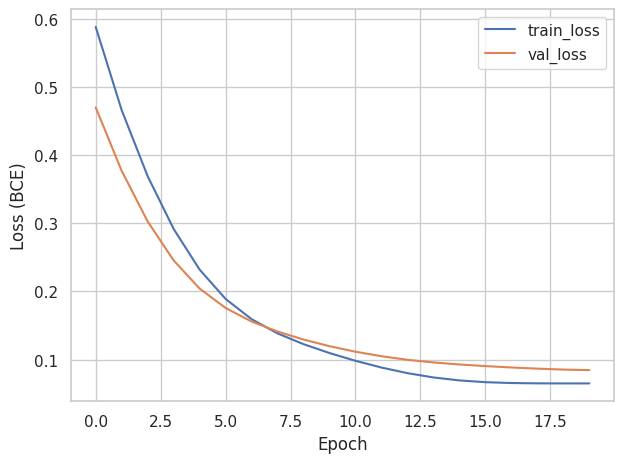

Test accuracy: 0.971


In [50]:
model_slothnet2 = SlothNet(4).to(device)
print(model_slothnet2)

torchinfo.summary(model_slothnet2, input_size=(1, 4))

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_slothnet2.parameters(), lr=0.05)

n_epochs = 20
history = {"train_loss": [], "val_loss": []}

for epoch in range(n_epochs):
    model_slothnet2.train()
    train_loss = criterion(model_slothnet2(X_train_tensor), y_train_tensor)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()


    model_slothnet2.eval()
    with torch.no_grad():
        val_loss = criterion(model_slothnet2(X_val_tensor), y_val_tensor)

    history["train_loss"].append(train_loss.item())
    history["val_loss"].append(val_loss.item())

plt.figure()
for key, values in history.items():
    plt.plot(values, label=key)
plt.xlabel("Epoch"); plt.ylabel("Loss (BCE)")
plt.legend(); plt.tight_layout(); plt.show()

model_slothnet2.eval()                       # evaluation mode
with torch.no_grad():              # no gradients needed for evaluation
    test_logits = model_slothnet2(X_test_tensor)
    test_probs  = torch.sigmoid(test_logits)   # logits -> probabilities in (0,1)
    test_preds  = (test_probs >= 0.5).float()  # probability -> class 0/1

y_true = y_test_tensor.cpu().numpy().ravel()
y_pred = test_preds.cpu().numpy().ravel()

accuracy = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {accuracy:.3f}")

SlothNet(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=1, bias=True)
)


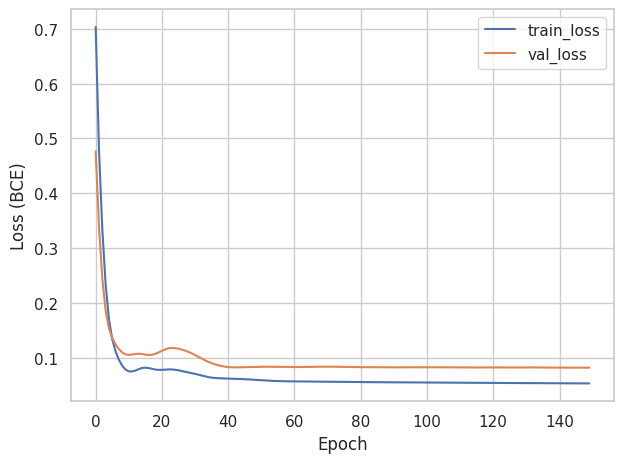

Test accuracy: 0.979


In [51]:
model_slothnet3 = SlothNet(4).to(device)
print(model_slothnet3)

torchinfo.summary(model_slothnet3, input_size=(1, 4))

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_slothnet3.parameters(), lr=0.1)

n_epochs = 150
history = {"train_loss": [], "val_loss": []}

for epoch in range(n_epochs):
    model_slothnet3.train()
    train_loss = criterion(model_slothnet3(X_train_tensor), y_train_tensor)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()


    model_slothnet3.eval()
    with torch.no_grad():
        val_loss = criterion(model_slothnet3(X_val_tensor), y_val_tensor)

    history["train_loss"].append(train_loss.item())
    history["val_loss"].append(val_loss.item())

plt.figure()
for key, values in history.items():
    plt.plot(values, label=key)
plt.xlabel("Epoch"); plt.ylabel("Loss (BCE)")
plt.legend(); plt.tight_layout(); plt.show()

model_slothnet3.eval()                       # evaluation mode
with torch.no_grad():              # no gradients needed for evaluation
    test_logits = model_slothnet3(X_test_tensor)
    test_probs  = torch.sigmoid(test_logits)   # logits -> probabilities in (0,1)
    test_preds  = (test_probs >= 0.5).float()  # probability -> class 0/1

y_true = y_test_tensor.cpu().numpy().ravel()
y_pred = test_preds.cpu().numpy().ravel()

accuracy = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {accuracy:.3f}")

## Activity 2 — Change the architecture 🏗️

Modify the network and see how it behaves. Try **at least two** of these:

- change the hidden layer size (e.g. `4`, `32`, `64`),
- **add a second hidden layer** (another `nn.Linear` + `nn.ReLU`),
- replace `nn.ReLU()` with `nn.Tanh()`.


In [63]:
class SlothNet1(nn.Module):
    def __init__(self, n_features):
        super().__init__()                     # 1) required first line
        self.fc1 = nn.Linear(n_features, 16)   # 2) define the layers
        self.fc2 = nn.Linear(16, 8)
        self.fc4 = nn.Linear(8, 1)

    def forward(self, x):                       # 3) describe the data flow
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = self.fc4(x)
        return x

SlothNet1(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=8, bias=True)
  (fc4): Linear(in_features=8, out_features=1, bias=True)
)


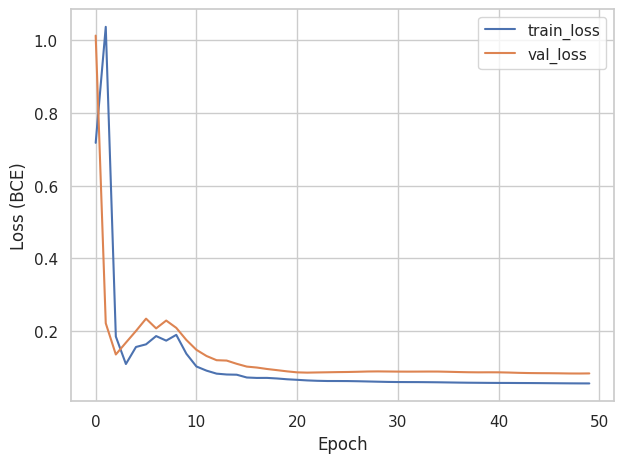

Test accuracy: 0.976


In [64]:
model_slothnet4 = SlothNet1(4).to(device)
print(model_slothnet4)

torchinfo.summary(model_slothnet4, input_size=(1, 4))

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_slothnet4.parameters(), lr=0.5)

n_epochs = 50
history = {"train_loss": [], "val_loss": []}

for epoch in range(n_epochs):
    model_slothnet4.train()
    train_loss = criterion(model_slothnet4(X_train_tensor), y_train_tensor)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()


    model_slothnet4.eval()
    with torch.no_grad():
        val_loss = criterion(model_slothnet4(X_val_tensor), y_val_tensor)

    history["train_loss"].append(train_loss.item())
    history["val_loss"].append(val_loss.item())

plt.figure()
for key, values in history.items():
    plt.plot(values, label=key)
plt.xlabel("Epoch"); plt.ylabel("Loss (BCE)")
plt.legend(); plt.tight_layout(); plt.show()

model_slothnet4.eval()                       # evaluation mode
with torch.no_grad():              # no gradients needed for evaluation
    test_logits = model_slothnet4(X_test_tensor)
    test_probs  = torch.sigmoid(test_logits)   # logits -> probabilities in (0,1)
    test_preds  = (test_probs >= 0.5).float()  # probability -> class 0/1

y_true = y_test_tensor.cpu().numpy().ravel()
y_pred = test_preds.cpu().numpy().ravel()

accuracy = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {accuracy:.3f}")

In [85]:
class SlothNet2(nn.Module):
    def __init__(self, n_features):
        super().__init__()                     # 1) required first line
        self.fc1 = nn.Linear(n_features,16)   # 2) define the layers
        self.fc2 = nn.Linear(16, 32)
        self.fc3 = nn.Linear(32, 16)
        self.fc4 = nn.Linear(16, 8)
        self.fc6 = nn.Linear(8, 1)

    def forward(self, x):                       # 3) describe the data flow
        x = torch.relu(self.fc1(x))
        x = torch.relu(self.fc2(x))
        x = torch.relu(self.fc3(x))
        x = torch.relu(self.fc4(x))
        #x = torch.relu(self.fc5(x))
        x = self.fc6(x)
        return x

SlothNet2(
  (fc1): Linear(in_features=4, out_features=16, bias=True)
  (fc2): Linear(in_features=16, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=8, bias=True)
  (fc6): Linear(in_features=8, out_features=1, bias=True)
)


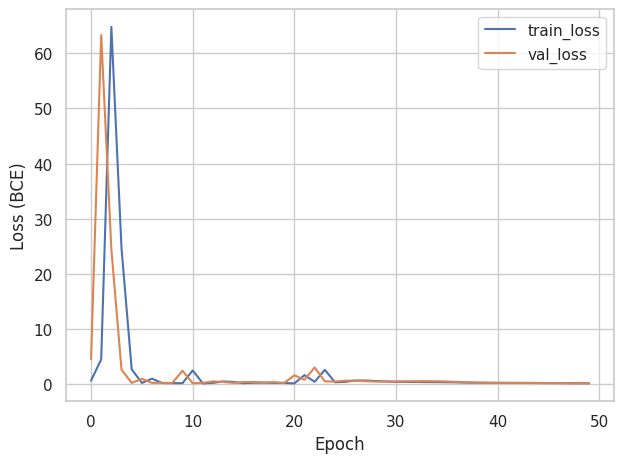

Test accuracy: 0.916


In [86]:
model_slothnet5 = SlothNet2(4).to(device)
print(model_slothnet5)

torchinfo.summary(model_slothnet5, input_size=(1, 4))

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.Adam(model_slothnet5.parameters(), lr=0.5)

n_epochs = 50
history = {"train_loss": [], "val_loss": []}

for epoch in range(n_epochs):
    model_slothnet5.train()
    train_loss = criterion(model_slothnet5(X_train_tensor), y_train_tensor)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()


    model_slothnet5.eval()
    with torch.no_grad():
        val_loss = criterion(model_slothnet5(X_val_tensor), y_val_tensor)

    history["train_loss"].append(train_loss.item())
    history["val_loss"].append(val_loss.item())

plt.figure()
for key, values in history.items():
    plt.plot(values, label=key)
plt.xlabel("Epoch"); plt.ylabel("Loss (BCE)")
plt.legend(); plt.tight_layout(); plt.show()

model_slothnet5.eval()                       # evaluation mode
with torch.no_grad():              # no gradients needed for evaluation
    test_logits = model_slothnet5(X_test_tensor)
    test_probs  = torch.sigmoid(test_logits)   # logits -> probabilities in (0,1)
    test_preds  = (test_probs >= 0.5).float()  # probability -> class 0/1

y_true = y_test_tensor.cpu().numpy().ravel()
y_pred = test_preds.cpu().numpy().ravel()

accuracy = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {accuracy:.3f}")

## Activity 3 — Swap the optimizer ⚙️

We used **Adam**. Classic gradient descent uses **SGD** (Stochastic Gradient Descent).

Replace the optimizer with `torch.optim.SGD(model.parameters(), lr=0.1)` and compare
the loss curves of Adam vs SGD (reuse `train_and_evaluate`, or adapt it to accept an
optimizer). Which one reaches a low loss **faster** here?


SlothNet1(
  (fc1): Linear(in_features=4, out_features=64, bias=True)
  (fc2): Linear(in_features=64, out_features=32, bias=True)
  (fc3): Linear(in_features=32, out_features=16, bias=True)
  (fc4): Linear(in_features=16, out_features=1, bias=True)
)


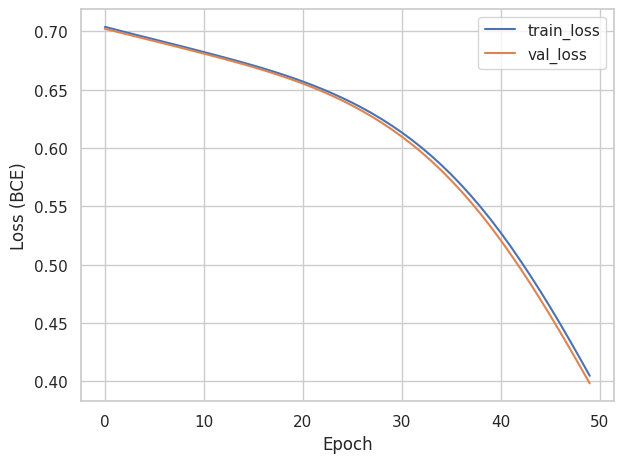

Test accuracy: 0.952


In [88]:
model_slothnet6 = SlothNet1(4).to(device)
print(model_slothnet6)

torchinfo.summary(model_slothnet6, input_size=(1, 4))

criterion = nn.BCEWithLogitsLoss()
optimizer = torch.optim.SGD(model_slothnet6.parameters(), lr=0.1)

n_epochs = 50
history = {"train_loss": [], "val_loss": []}

for epoch in range(n_epochs):
    model_slothnet6.train()
    train_loss = criterion(model_slothnet6(X_train_tensor), y_train_tensor)
    optimizer.zero_grad()
    train_loss.backward()
    optimizer.step()


    model_slothnet6.eval()
    with torch.no_grad():
        val_loss = criterion(model_slothnet6(X_val_tensor), y_val_tensor)

    history["train_loss"].append(train_loss.item())
    history["val_loss"].append(val_loss.item())

plt.figure()
for key, values in history.items():
    plt.plot(values, label=key)
plt.xlabel("Epoch"); plt.ylabel("Loss (BCE)")
plt.legend(); plt.tight_layout(); plt.show()

model_slothnet6.eval()                       # evaluation mode
with torch.no_grad():              # no gradients needed for evaluation
    test_logits = model_slothnet6(X_test_tensor)
    test_probs  = torch.sigmoid(test_logits)   # logits -> probabilities in (0,1)
    test_preds  = (test_probs >= 0.5).float()  # probability -> class 0/1

y_true = y_test_tensor.cpu().numpy().ravel()
y_pred = test_preds.cpu().numpy().ravel()

accuracy = accuracy_score(y_true, y_pred)
print(f"Test accuracy: {accuracy:.3f}")